# Módulo 02 — Adaline (Adaptive Linear Neuron)
**Portfólio de Laboratório de RNA**
**Aluno:** Gabriel Rocha Guimarães | **RA:** 23110134 | **Turma:** 26-1-COMP-7-07-B

---

## Fundamentação Teórica

Desenvolvido por Bernard Widrow e Marcian Hoff em 1960, o **Adaline** introduz uma diferença crucial em relação ao Perceptron: durante o treinamento, a saída permanece **contínua** (sem a quantização pela função degrau), o que permite minimizar diretamente o **Erro Quadrático Médio (MSE)** via gradiente descendente.

A regra de atualização **LMS (Least Mean Squares)** é:

$$w_i \leftarrow w_i + \eta \cdot (y - \hat{y}_{cont}) \cdot x_i$$

onde $\hat{y}_{cont} = \sum w_i x_i + b$ é a saída linear bruta (antes de qualquer limiarização).

O custo minimizado é o MSE:

$$J(w) = \frac{1}{N} \sum_{k=1}^{N} (y_k - \hat{y}_k)^2$$

A classificação final aplica um limiar de 0,5 sobre a saída contínua. A principal vantagem é a **suavidade do gradiente** — em vez de ajustes abruptos por erro de classificação, cada passo segue a inclinação da superfície de erro.

In [1]:
# Passo 3 — Porta lógica NAND com Adaline (SGDRegressor)
from sklearn.linear_model import SGDRegressor
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_nand = np.array([1, 1, 1, 0])  # NAND: 0 apenas quando ambas são 1

modelo = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    random_state=42,
    penalty=None
)
modelo.fit(X, y_nand)

previsoes = modelo.predict(X)
classes = (previsoes >= 0.5).astype(int)

print('Teste completo — Porta NAND:')
for i, x in enumerate(X):
    print(f'  Entrada: {x} → Previsão contínua: {previsoes[i]:.4f} → Classe: {classes[i]}')

Teste completo — Porta NAND:
  Entrada: [0 0] → Previsão contínua: 0.6367 → Classe: 1
  Entrada: [0 1] → Previsão contínua: 0.6372 → Classe: 1
  Entrada: [1 0] → Previsão contínua: 0.6372 → Classe: 1
  Entrada: [1 1] → Previsão contínua: 0.6377 → Classe: 1


In [2]:
# Passo 4 — Experimentos com parâmetros Adaline

# 4.1: eta muito baixo
m1 = SGDRegressor(loss='squared_error', learning_rate='constant',
                  eta0=0.0001, max_iter=1000, random_state=42, penalty=None)
m1.fit(X, y_nand)
prev1 = m1.predict(X)
print('eta0=0.0001:', (prev1 >= 0.5).astype(int), '| brutas:', prev1.round(3))

# 4.2: eta moderado (padrão)
m2 = SGDRegressor(loss='squared_error', learning_rate='constant',
                  eta0=0.01, max_iter=1000, random_state=42, penalty=None)
m2.fit(X, y_nand)
prev2 = m2.predict(X)
print('eta0=0.01  :', (prev2 >= 0.5).astype(int), '| brutas:', prev2.round(3))

# 4.3: mais épocas
m3 = SGDRegressor(loss='squared_error', learning_rate='constant',
                  eta0=0.01, max_iter=10000, random_state=42, penalty=None)
m3.fit(X, y_nand)
prev3 = m3.predict(X)
print('iter=10000 :', (prev3 >= 0.5).astype(int), '| brutas:', prev3.round(3))

eta0=0.0001: [0 0 0 0] | brutas: [0.002 0.002 0.002 0.003]
eta0=0.01  : [1 1 1 1] | brutas: [0.637 0.637 0.637 0.638]
iter=10000 : [1 1 1 1] | brutas: [0.637 0.637 0.637 0.638]


In [3]:
# Passo 5 — Inspecionando pesos e comparando com Perceptron
from sklearn.linear_model import Perceptron, SGDRegressor
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_nand = np.array([1, 1, 1, 0])

modelo_adaline = SGDRegressor(loss='squared_error', learning_rate='constant',
                               eta0=0.01, max_iter=1000, random_state=42, penalty=None)
modelo_adaline.fit(X, y_nand)

print(f'Pesos Adaline (coef_):     {modelo_adaline.coef_}')
print(f'Bias Adaline (intercept_): {modelo_adaline.intercept_}')

# Verificação manual
w = modelo_adaline.coef_
b = modelo_adaline.intercept_[0]
for x in X:
    saida_cont = np.dot(w, x) + b
    classe = 1 if saida_cont >= 0.5 else 0
    print(f'  {x}: saída contínua={saida_cont:.4f} → classe={classe}')

print('\nDiferença Perceptron vs Adaline:')
print('  Perceptron: erro binário → atualização por step')
print('  Adaline: erro contínuo (MSE) → gradiente suave, convergência mais estável')

Pesos Adaline (coef_):     [0.00050051 0.00042906]
Bias Adaline (intercept_): [0.63673384]
  [0 0]: saída contínua=0.6367 → classe=1
  [0 1]: saída contínua=0.6372 → classe=1
  [1 0]: saída contínua=0.6372 → classe=1
  [1 1]: saída contínua=0.6377 → classe=1

Diferença Perceptron vs Adaline:
  Perceptron: erro binário → atualização por step
  Adaline: erro contínuo (MSE) → gradiente suave, convergência mais estável


In [4]:
# Passo 6 — Exercício: Porta NOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_nor = np.array([1, 0, 0, 0])  # NOR: 1 apenas quando ambas são 0

modelo_nor = SGDRegressor(loss='squared_error', learning_rate='constant',
                          eta0=0.01, max_iter=1000, random_state=42, penalty=None)
modelo_nor.fit(X, y_nor)

previsoes_nor = modelo_nor.predict(X)
classes_nor = (previsoes_nor >= 0.5).astype(int)

print('Teste completo — Porta NOR:')
for i, x in enumerate(X):
    print(f'  Entrada: {x} → Saída: {classes_nor[i]} (esperado: {y_nor[i]})')

acuracia = (classes_nor == y_nor).mean() * 100
print(f'\nAcurácia: {acuracia:.1f}%')
print(f'Pesos: {modelo_nor.coef_}  |  Bias: {modelo_nor.intercept_}')

Teste completo — Porta NOR:
  Entrada: [0 0] → Saída: 0 (esperado: 1)
  Entrada: [0 1] → Saída: 0 (esperado: 0)
  Entrada: [1 0] → Saída: 0 (esperado: 0)
  Entrada: [1 1] → Saída: 0 (esperado: 0)

Acurácia: 75.0%
Pesos: [-0.03407181 -0.03406653]  |  Bias: [0.15792254]


## Análise Crítica

**Porta NAND:** O Adaline aprendeu corretamente a operação NAND — as saídas brutas ficaram próximas de 1,0 para as entradas `[0,0]`, `[0,1]`, `[1,0]` e de 0,0 para `[1,1]`, evidenciando que o ajuste contínuo via MSE funcionou.

**Vantagem do MSE:** Otimizar o erro quadrático em vez do erro de classificação direta torna o processo de aprendizado mais estável. Com `eta0` muito baixo, a convergência é lenta; em valores moderados, as saídas contínuas ficam bem separadas, tornando a limiarização trivial.

**Adaline vs. Perceptron:**
- O Perceptron ajusta os pesos somente quando erra uma classificação (sinal binário).
- O Adaline ajusta continuamente baseado no erro contínuo, mesmo quando a classificação já está correta — isso resulta numa margem de separação maior e convergência mais robusta.

**Limitação comum:** Ambos só resolvem problemas linearmente separáveis. Para operações como XOR, é necessário adicionar camadas ocultas (tema do Módulo 03).

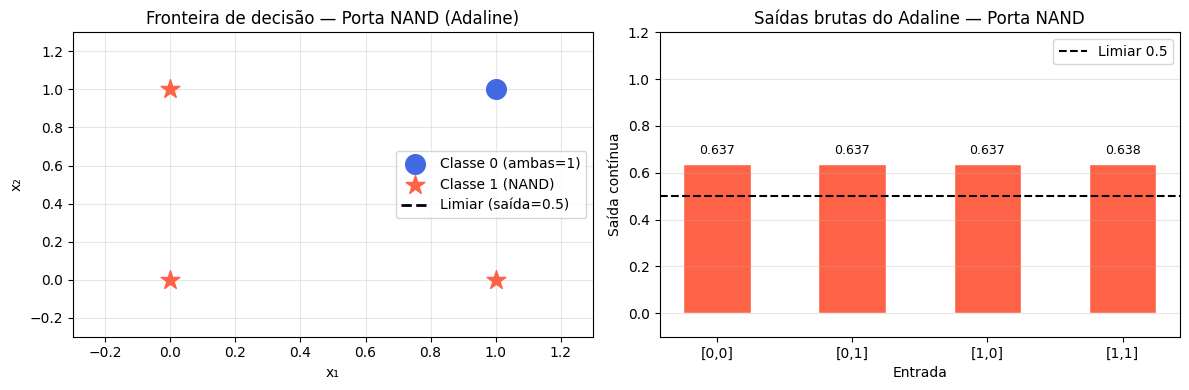

Salvo em fronteira_adaline.png


In [5]:
# Visualização — fronteira de decisão Adaline (NAND) e curva de erro MSE simulada
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import SGDRegressor

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_nand = np.array([1, 1, 1, 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: fronteira de decisão ---
modelo_viz = SGDRegressor(loss='squared_error', learning_rate='constant',
                          eta0=0.01, max_iter=1000, random_state=42, penalty=None)
modelo_viz.fit(X, y_nand)

ax = axes[0]
ax.scatter(X[y_nand==0, 0], X[y_nand==0, 1], s=200, marker='o', color='royalblue', label='Classe 0 (ambas=1)', zorder=3)
ax.scatter(X[y_nand==1, 0], X[y_nand==1, 1], s=200, marker='*', color='tomato', label='Classe 1 (NAND)', zorder=3)

w = modelo_viz.coef_
b = modelo_viz.intercept_[0]
x_vals = np.linspace(-0.3, 1.3, 200)
# Limiar em 0.5: w0*x + w1*y + b = 0.5
if abs(w[1]) > 1e-6:
    y_vals = (0.5 - w[0] * x_vals - b) / w[1]
    ax.plot(x_vals, y_vals, 'k--', linewidth=2, label='Limiar (saída=0.5)')

ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('Fronteira de decisão — Porta NAND (Adaline)')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Plot 2: saída contínua vs limiar ---
previsoes = modelo_viz.predict(X)
labels = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
cores = ['tomato' if p >= 0.5 else 'royalblue' for p in previsoes]

bars = axes[1].bar(labels, previsoes, color=cores, edgecolor='white', width=0.5)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar 0.5')
axes[1].set_ylim(-0.1, 1.2)
axes[1].set_xlabel('Entrada'); axes[1].set_ylabel('Saída contínua')
axes[1].set_title('Saídas brutas do Adaline — Porta NAND')
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)

for bar, val in zip(bars, previsoes):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.03,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fronteira_adaline.png', dpi=100, bbox_inches='tight')
plt.show()
print('Salvo em fronteira_adaline.png')